# Kazakh Bank Risk Assistant
Cognitive AI prototype: **Perception → Attention → Memory → Knowledge Representation**

| Term | Meaning |
|---|---|
| Assets | everything the bank owns |
| Loans | money the bank lent |
| NPL 90+ | loans more than 90 days overdue (official "bad loan" measure) |
| NPL share | NPL 90+ / all loans (watch level 3%) |
| Deposits | money clients keep in the bank |
| k2 | capital adequacy: own capital / risk-weighted assets (minimum 8%) |

## 1. Setup

In [1]:
import warnings, logging
warnings.filterwarnings("ignore"); logging.disable(logging.WARNING)

import re
from datetime import date
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from kzbank.storage.db import fetch_all

TODAY = date(2026, 9, 28)
RAW = Path("../data/raw")
pd.set_option("display.max_colwidth", 80)

SHORT = {
    "Народный Банк Казахстана (Halyk Bank)": "Halyk", "Банк ЦентрКредит": "BCC", "Отбасы банк": "Otbasy",
    "ForteBank": "ForteBank", "Alatau City Bank": "Alatau City", "Фридом Банк Казахстан": "Freedom",
    "Bank RBK": "Bank RBK", "Евразийский банк": "Eurasian", "Altyn Bank": "Altyn", "Нурбанк": "Nurbank",
    "Home Credit Bank": "Home Credit", "Bereke Bank": "Bereke", "KMF Банк": "KMF",
    "Kaspi Bank": "Kaspi", "VTB Kazakhstan": "VTB", "Citibank Kazakhstan": "Citibank",
    "Bank of China Kazakhstan": "Bank of China", "Shinhan Bank Kazakhstan": "Shinhan", "ICBC Almaty": "ICBC",
    "Zaman Bank": "Zaman", "KZI Bank": "KZI", "коммерческий банк биэнкей": "BNK", "исламский банк adcb": "ADCB",
    "казкоммерцбанк": "Kazkommertsbank", "BTA Bank": "BTA", "delta bank": "Delta Bank", "tengri bank": "Tengri",
    "qazaq banki": "Qazaq Banki", "asiacredit bank": "AsiaCredit", "эксимбанк казахстан": "Eximbank",
    "банк астаны": "Bank Astany", "казинвестбанк": "Kazinvestbank", "атфбанк": "ATFBank",
    "альфа-банк": "Alfa-Bank", "Temirbank": "Temirbank", "альянс банк": "Alliance Bank",
    "capital bank kazakhstan": "Capital Bank",
}
short = lambda name: SHORT.get(name, name.title())

BLUE, ORANGE, AQUA, YELLOW, RED, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e34948", "#8a8984"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
                     "axes.edgecolor": "#b8b7b0", "font.size": 10, "lines.linewidth": 2})

## 2. Data collection

| Source | Content | Method |
|---|---|---|
| National Bank of Kazakhstan, statistics | monthly figures for every bank, 2005-2026: assets, loans, NPL 90+, deposits, profit, capital ratios | scraper over 22 yearly pages, Excel download |
| KASE (kase.kz) | quarterly balance sheets (form 700-Н) of 13 listed banks | scraper over issuer pages, Excel download |
| National Bank of Kazakhstan | 70 banking regulations | saved pages + code download of each act |
| National Bank of Kazakhstan | daily exchange rates | RSS |

## 3. Preprocessing

### 3.1 Raw data

In [2]:
def files(pattern): return sorted(f for f in RAW.glob(pattern) if f.suffix.lower() in (".xlsx", ".xls", ".docx", ".doc", ".html"))
groups = {
    "NBK statistics (scraped)": files("nbk_stats/*"),
    "KASE bank reports (scraped)": files("kase/*/*"),
    "NBK regulations (downloaded)": files("nbk/*"),
    "NBK website pages (saved in browser)": files("*.html"),
}
pd.DataFrame([(k, len(v), round(sum(f.stat().st_size for f in v) / 1e6, 1)) for k, v in groups.items()],
             columns=["source", "files", "MB"])

,source,files,MB
0,NBK statistics (scraped),46,35.0
1,KASE bank reports (scraped),557,464.7
2,NBK regulations (downloaded),107,25.0
3,NBK website pages (saved in browser),3,2.1


### 3.2 Raw statistics file

In [3]:
from kzbank.ingest.nbk_stats import _sheets, parse_prudential, parse_capital_assets, canonical_bank
f = sorted((RAW / "nbk_stats").glob("prudential_134501.*"))[0]
name, rows = _sheets(f)[-1]
print(f.name, "| sheet", name.strip(), "| one sheet per month")
pd.DataFrame(rows[6:12]).iloc[:, :6]

prudential_134501.xlsx | sheet 01.08.2026 | one sheet per month


,0,1,2,3,4,5
0,1,"АО ""Народный Банк Казахстана""",3728055919,0.194,0.194,0.194
1,2,"АО ""Kaspi Bank""",1522661391,0.143,0.143,0.143
2,3,"АО ""Банк ЦентрКредит""",909152188,0.187,0.187,0.187
3,4,"АО ""Отбасы банк""",779994039,0.296,0.296,0.296
4,5,"АО ""ForteBank""",904176133,0.177,0.230,0.231
5,6,"АО ""Alatau City Bank""",975868427,0.413,0.413,0.464


### 3.3 Parsing

In [4]:
parsed = []
for f in sorted((RAW / "nbk_stats").glob("prudential_*")):
    parsed += parse_prudential(f)
for f in sorted((RAW / "nbk_stats").glob("capital_assets_*")):
    parsed += parse_capital_assets(f)
p = pd.DataFrame([r.__dict__ for r in parsed])
print(f"{len(p):,} values | {p.bank.nunique()} printed bank names | {p.period.nunique()} months")

168,782 values | 192 printed bank names | 252 months


### 3.4 Bank identity: names → one history per bank

In [5]:
p["canonical"] = p.bank.map(canonical_bank)
examples = ['ДБ АО "Сбербанк"', 'АО "Bereke Bank" (ДБ Lesha Bank LLC (Public))', 'АО "Цеснабанк"',
            'АО "First Heartland Jýsan Bank"', 'АО "Alatau City Bank"', 'АО "Жилстройсбербанк Казахстана"']
pd.DataFrame({"printed name": examples, "stored as": [canonical_bank(x) for x in examples]})

,printed name,stored as
0,"ДБ АО ""Сбербанк""",Bereke Bank
1,"АО ""Bereke Bank"" (ДБ Lesha Bank LLC (Public))",Bereke Bank
2,"АО ""Цеснабанк""",Alatau City Bank
3,"АО ""First Heartland Jýsan Bank""",Alatau City Bank
4,"АО ""Alatau City Bank""",Alatau City Bank
5,"АО ""Жилстройсбербанк Казахстана""",Otbasy Bank


In [6]:
print(f"{p.bank.nunique()} printed names -> {p.canonical.nunique()} banks")

192 printed names -> 79 banks


### 3.5 Quality check: two independent sources

In [7]:
chk = pd.DataFrame(fetch_all("""
    SELECT e.name_ru AS bank, round(m1.value / 1e12, 3) AS kase_700n, round(m2.value / 1e12, 3) AS nbk_statistics
    FROM metrics m1 JOIN metrics m2 ON m1.bin = m2.bin AND m1.period = m2.period
    JOIN entities e ON e.bin = m1.bin
    WHERE m1.metric = 'assets' AND m2.metric = 'nbk_assets' AND m1.period = '2026-06-30'
    ORDER BY m1.value DESC"""))
chk["bank"] = chk.bank.map(short)
chk["difference, %"] = ((chk.nbk_statistics / chk.kase_700n - 1) * 100).round(2)
chk.rename(columns={"kase_700n": "assets from KASE 700-Н, trln", "nbk_statistics": "assets from NBK, trln"})

,bank,"assets from KASE 700-Н, trln","assets from NBK, trln","difference, %"
0,Halyk,21.196,21.196,0.00
1,BCC,8.859,8.859,0.00
2,Otbasy,5.912,5.912,0.00
3,ForteBank,5.150,5.150,0.00
4,Alatau City,3.261,3.261,0.00
5,Freedom,2.957,2.957,0.00
6,Bank RBK,2.832,2.832,0.00
7,Eurasian,2.751,2.751,0.00
8,Home Credit,1.427,1.427,0.00
9,Altyn,1.264,1.264,0.00


### 3.6 Final dataset

In [8]:
raw = pd.DataFrame(fetch_all("""
    SELECT e.name_ru AS bank, m.period, m.metric, m.value
    FROM metrics m JOIN entities e USING (bin) JOIN documents d ON d.id = m.source_doc
    WHERE d.source = 'nbk_stats'"""))
raw["value"] = raw.value.astype(float)          # Postgres NUMERIC arrives as Decimal
df = raw.pivot_table(index=["bank", "period"], columns="metric", values="value").reset_index()
df = df.replace([np.inf, -np.inf], np.nan)
df["bank"] = df.bank.map(short)
df["period"] = pd.to_datetime(df.period)
df["npl_share"] = df.nbk_npl90 / df.nbk_loans
df["equity_ratio"] = df.nbk_equity / df.nbk_assets
df["loans_to_deposits"] = df.nbk_loans / df.nbk_deposits
df = df.replace([np.inf, -np.inf], np.nan)     # banks with zero loans or deposits
print(df.shape)
df[["bank", "period", "nbk_assets", "nbk_loans", "nbk_npl90", "nbk_deposits", "k2"]].dropna().tail()

(7878, 25)


metric,bank,period,nbk_assets,nbk_loans,nbk_npl90,nbk_deposits,k2
7845,Eximbank,2018-03-31,7.604856e+10,4.435512e+10,1.611414e+09,2.657838e+10,0.175
7846,Eximbank,2018-04-30,7.154970e+10,4.289714e+10,4.784275e+09,2.244468e+10,0.180
7847,Eximbank,2018-05-31,6.524355e+10,4.082666e+10,5.940807e+09,1.884697e+10,0.190
7848,Eximbank,2018-06-30,6.371391e+10,3.995093e+10,1.766166e+10,1.732077e+10,0.209
7849,Eximbank,2018-07-31,5.969052e+10,3.730622e+10,2.002815e+10,1.317234e+10,0.221


### 3.7 Regulations: text → chunks → embeddings

In [9]:
from kzbank.ingest.nbk_acts import parse_act
from kzbank.extract.chunking import chunk_document
from kzbank.retrieval.embed import embed_texts
act = parse_act(RAW / "nbk/133064_PP 100 ot 241225 s izm 94 rus.docx")
pieces = chunk_document(act.text)
print(f"{len(act.text):,} characters -> {len(pieces)} chunks -> {embed_texts([pieces[0].text]).shape[1]}-d embeddings")
pd.DataFrame([{"article": x.article_ref, "text": x.text[:100].replace(chr(10), " ")} for x in pieces[:4]])

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

357,874 characters -> 811 chunks -> 1024-d embeddings


,article,text
0,Преамбула,«ҚАЗАҚСТАН РЕСПУБЛИКАСЫНЫҢ ҰЛТТЫҚ БАНКІ» РЕСПУБЛИКАЛЫҚ МЕМЛЕКЕТТІК МЕКЕМЕСІ...
1,пункт 1,1. ПП НБ РК № 94 от 31.07.2026 г.) В соответствии с подпунктом 48) абзаца в...
2,пункт 1,1. Утвердить прилагаемые Правила представления отчетности о выполнении пруде...
3,пункт 2,2. Признать утратившими силу некоторые постановления Правления Национального...


## 4. Exploratory data analysis

### 4.1 Number of banks

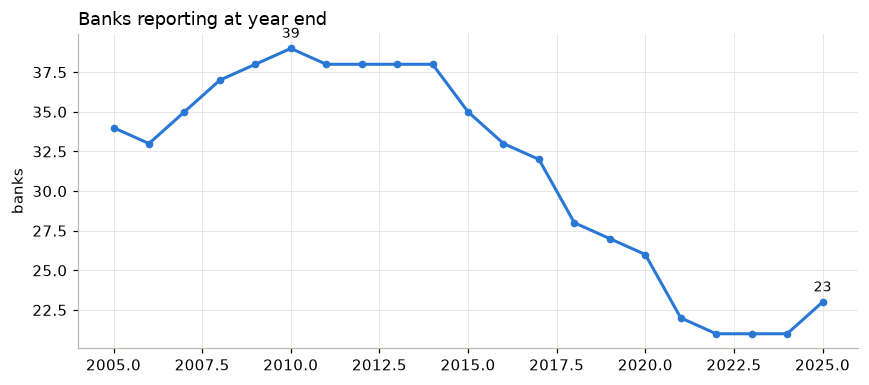

In [10]:
n = df[df.period.dt.month == 12].groupby(df.period.dt.year).bank.nunique()
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(n.index, n.values, color=BLUE, marker="o", markersize=4)
for y in (n.idxmax(), n.index[-1]):
    ax.annotate(f"{n[y]}", (y, n[y]), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=9)
ax.set_ylabel("banks"); ax.set_title("Banks reporting at year end", loc="left"); plt.tight_layout(); plt.show()

### 4.2 Descriptive statistics (latest month)

In [11]:
latest = df.period.max()
snap = df[df.period == latest].set_index("bank").sort_values("nbk_assets", ascending=False)
snap[["npl_share", "k2", "k4", "equity_ratio", "loans_to_deposits"]].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
metric,,,,,,,,
npl_share,20.0,0.041,0.027,0.001,0.016,0.040,0.066,0.093
k2,23.0,0.369,0.302,0.143,0.186,0.241,0.429,1.327
k4,23.0,3.529,5.341,0.932,1.598,2.102,3.058,27.273
equity_ratio,23.0,0.198,0.137,0.080,0.130,0.148,0.179,0.641
loans_to_deposits,22.0,1.958,3.707,0.192,0.753,0.848,1.170,17.768


### 4.3 Bank size

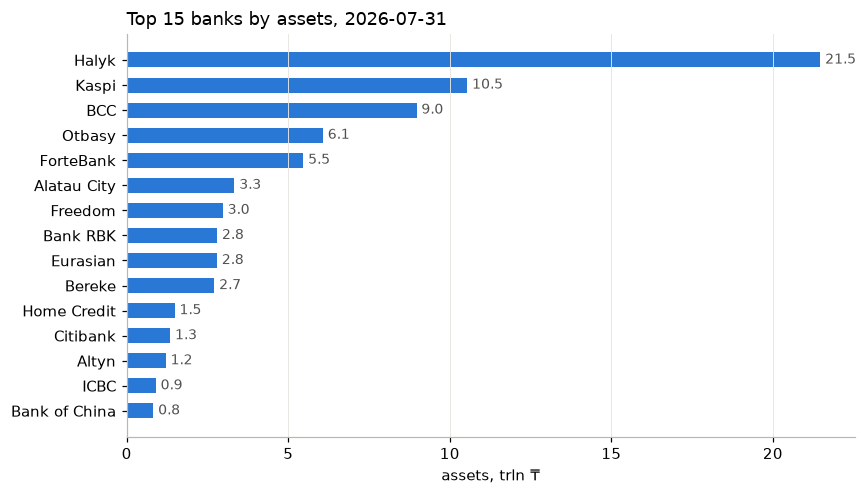

In [12]:
s = (snap.nbk_assets / 1e12).sort_values().tail(15)
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.barh(s.index, s.values, color=BLUE, height=0.6)
for y, v in enumerate(s.values): ax.text(v + 0.15, y, f"{v:.1f}", va="center", fontsize=9, color="#52514e")
ax.set_xlabel("assets, trln ₸"); ax.set_title(f"Top 15 banks by assets, {latest.date()}", loc="left")
ax.grid(axis="y", visible=False); plt.tight_layout(); plt.show()

### 4.4 NPL 90+ share

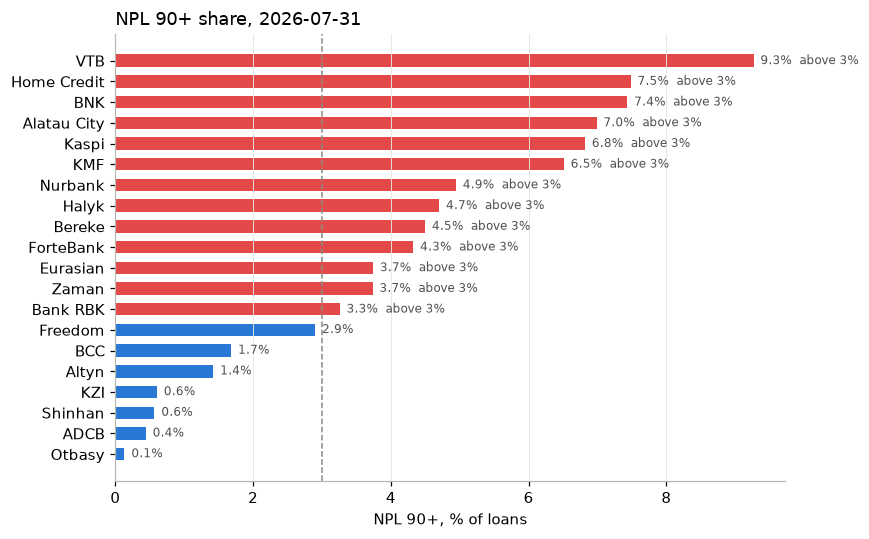

In [13]:
s = (snap.npl_share.dropna() * 100).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(s.index, s.values, color=[RED if v > 3 else BLUE for v in s.values], height=0.6)
for y, v in enumerate(s.values):
    ax.text(v + 0.1, y, f"{v:.1f}%" + ("  above 3%" if v > 3 else ""), va="center", fontsize=8, color="#52514e")
ax.axvline(3, color=GREY, ls="--", lw=1)
ax.set_xlabel("NPL 90+, % of loans"); ax.set_title(f"NPL 90+ share, {latest.date()}", loc="left")
ax.grid(axis="y", visible=False); plt.tight_layout(); plt.show()

### 4.5 Sector NPL 90+ over time

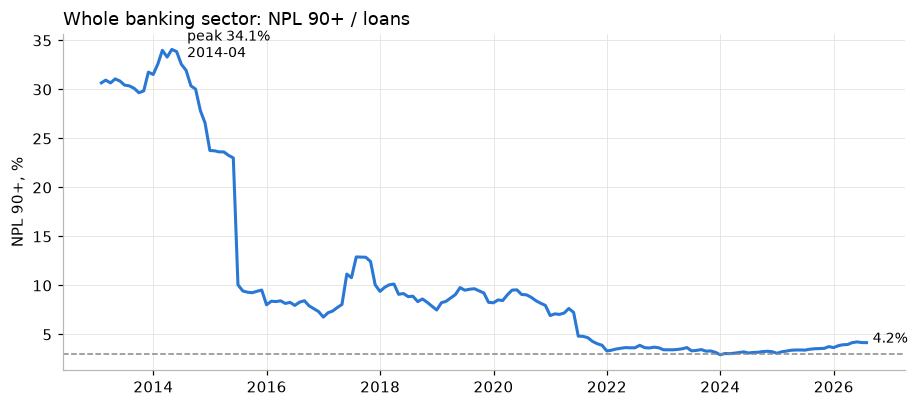

In [14]:
sec = df.dropna(subset=["nbk_npl90", "nbk_loans"]).groupby("period")[["nbk_npl90", "nbk_loans"]].sum()
sec = (sec.nbk_npl90 / sec.nbk_loans * 100)
fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.plot(sec.index, sec.values, color=BLUE)
peak = sec.idxmax(); ax.annotate(f"peak {sec.max():.1f}%\n{peak:%Y-%m}", (peak, sec.max()), xytext=(10, -5),
                                 textcoords="offset points", fontsize=9)
ax.annotate(f"{sec.iloc[-1]:.1f}%", (sec.index[-1], sec.iloc[-1]), xytext=(4, 0), textcoords="offset points", fontsize=9)
ax.axhline(3, color=GREY, ls="--", lw=1)
ax.set_ylabel("NPL 90+, %"); ax.set_title("Whole banking sector: NPL 90+ / loans", loc="left"); plt.tight_layout(); plt.show()

### 4.6 NPL 90+ by bank over time

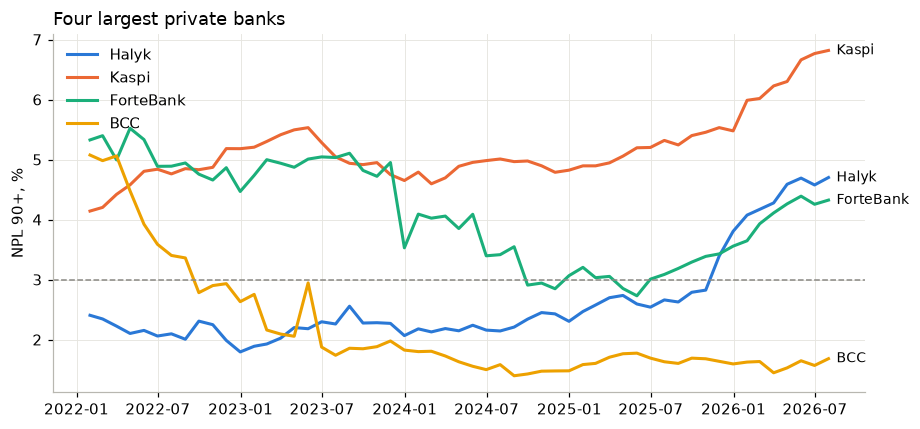

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 4))
for bank, color in zip(["Halyk", "Kaspi", "ForteBank", "BCC"], [BLUE, ORANGE, AQUA, YELLOW]):
    d = df[(df.bank == bank) & (df.period >= "2022-01-01")].dropna(subset=["npl_share"]).sort_values("period")
    ax.plot(d.period, d.npl_share * 100, color=color, label=bank)
    ax.text(d.period.iloc[-1], d.npl_share.iloc[-1] * 100, f"  {bank}", fontsize=9, va="center")
ax.axhline(3, color=GREY, ls="--", lw=1)
ax.set_ylabel("NPL 90+, %"); ax.set_title("Four largest private banks", loc="left")
ax.legend(frameon=False, loc="upper left"); plt.tight_layout(); plt.show()

### 4.7 Capital adequacy k2 (latest month)

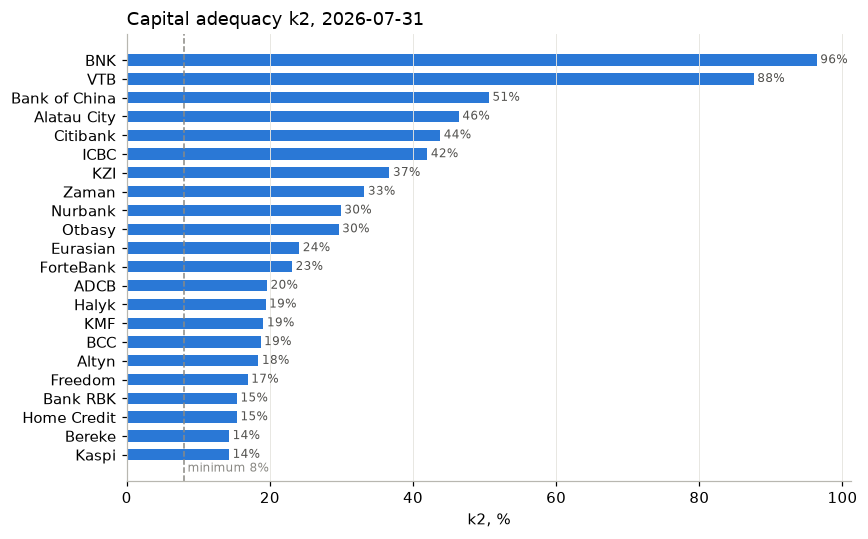

In [16]:
s = (snap.k2.dropna() * 100).sort_values()
s = s[s < 100]                                # a few tiny banks sit far above 100%
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(s.index, s.values, color=[RED if v < 8 else BLUE for v in s.values], height=0.6)
for y, v in enumerate(s.values): ax.text(v + 0.5, y, f"{v:.0f}%", va="center", fontsize=8, color="#52514e")
ax.axvline(8, color=GREY, ls="--", lw=1); ax.text(8.5, -0.9, "minimum 8%", fontsize=8, color=GREY)
ax.set_xlabel("k2, %"); ax.set_title(f"Capital adequacy k2, {latest.date()}", loc="left")
ax.grid(axis="y", visible=False); plt.tight_layout(); plt.show()

### 4.8 Banks that failed: capital before exit

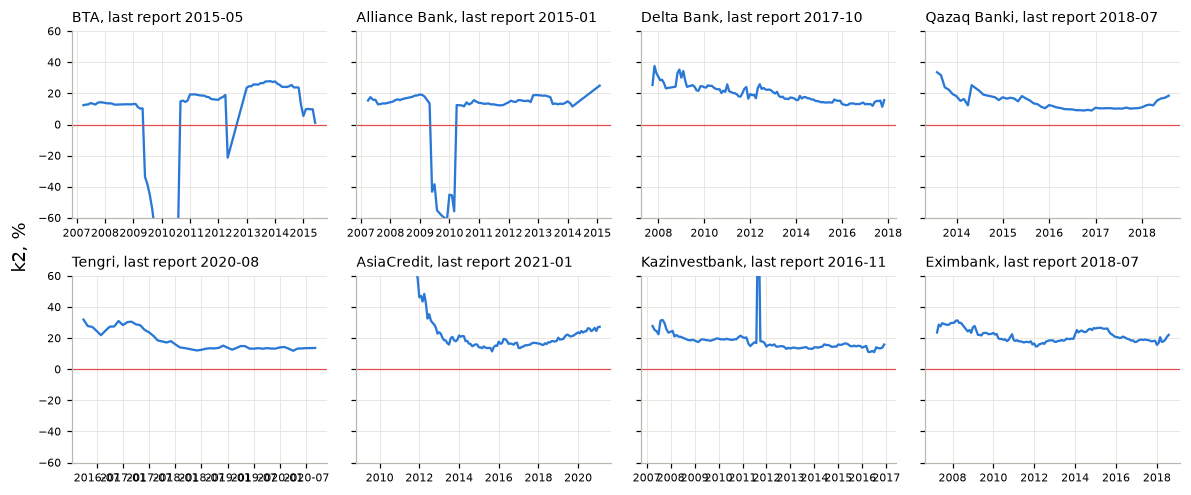

In [17]:
failed = ["BTA", "Alliance Bank", "Delta Bank", "Qazaq Banki", "Tengri", "AsiaCredit", "Kazinvestbank", "Eximbank"]
fig, axes = plt.subplots(2, 4, figsize=(11, 4.6), sharey=True)
for ax, bank in zip(axes.flat, failed):
    d = df[df.bank == bank].dropna(subset=["k2"]).sort_values("period")
    if d.empty:
        ax.set_axis_off(); continue
    ax.plot(d.period, d.k2 * 100, color=BLUE, lw=1.5)
    ax.axhline(0, color=RED, lw=0.8); ax.set_ylim(-60, 60)
    ax.set_title(f"{bank}, last report {d.period.iloc[-1]:%Y-%m}", fontsize=9, loc="left")
    ax.tick_params(labelsize=7)
fig.supylabel("k2, %"); plt.tight_layout(); plt.show()

### 4.9 Correlation of ratios (all bank-months)

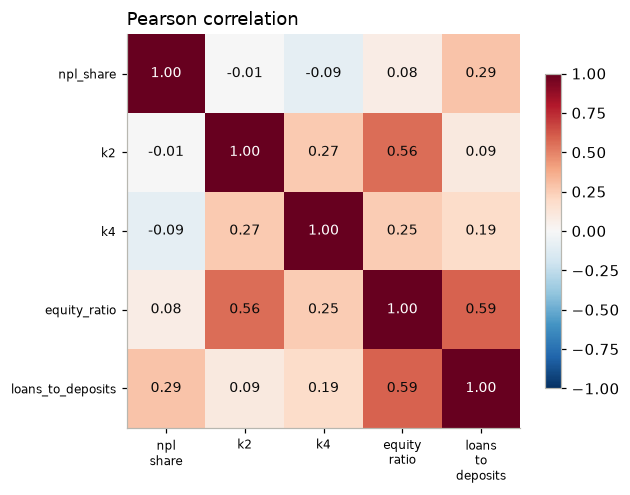

In [18]:
ratios = ["npl_share", "k2", "k4", "equity_ratio", "loans_to_deposits"]
corr = df[ratios].replace([np.inf, -np.inf], np.nan).clip(-5, 5).corr()
fig, ax = plt.subplots(figsize=(5.8, 4.6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(ratios)), [r.replace("_", "\n") for r in ratios], fontsize=8)
ax.set_yticks(range(len(ratios)), ratios, fontsize=8)
for i in range(len(ratios)):
    for j in range(len(ratios)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9, color="white" if abs(v) > 0.6 else "#0b0b0b")
ax.grid(False); fig.colorbar(im, ax=ax, shrink=0.8); ax.set_title("Pearson correlation", loc="left")
plt.tight_layout(); plt.show()

## 5. Module 1: Perception

In [19]:
from kzbank.agent.perception import perceive
from kzbank.agent import knowledge as kb
INTENT = {"risk": "risk check", "compare": "comparison", "metric": "single figure",
          "fx": "exchange rate", "legal": "regulation", "compliance": "norm check"}
MEANING = {"assets": "активы", "deposits": "вклады", "overdue_loans": "просрочка / NPL",
           "net_income": "прибыль", "equity": "капитал"}
qs = ["Соблюдает ли Kaspi норматив k2?", "Сравни активы Kaspi и Halyk", "Какой NPL у Нурбанка?",
      "Какой курс доллара был вчера?",
      "В какие сроки банковский конгломерат представляет отчет о выполнении пруденциальных нормативов?"]
rows = []
for q in qs:
    pr = perceive(q, today=TODAY)
    rows.append({"input": q, "intent": INTENT[pr.intent], "banks": ", ".join(short(c) for c in pr.companies) or "-",
                 "measure": ", ".join(MEANING.get(x, x) for x in pr.metrics) or "-",
                 "ratio": ", ".join(pr.ratios) or "-", "currency": ", ".join(pr.currencies) or "-",
                 "date": pr.on_date or "-"})
pd.DataFrame(rows)

,input,intent,banks,measure,ratio,currency,date
0,Соблюдает ли Kaspi норматив k2?,norm check,Kaspi,-,k2,-,-
1,Сравни активы Kaspi и Halyk,comparison,"Kaspi, Halyk",активы,-,-,-
2,Какой NPL у Нурбанка?,risk check,Nurbank,просрочка / NPL,-,-,-
3,Какой курс доллара был вчера?,exchange rate,-,-,-,USD,2026-09-27
4,В какие сроки банковский конгломерат представляет отчет о выполнении пруденц...,regulation,-,-,-,-,-


## 6. Module 2: Attention

### 6.1 Risk ranking of banks

In [20]:
rows = []
for b in kb.kz_banks():
    r, tr = kb.rule_npl_risk(b), kb.rule_trend(b)
    if "npl_share" in r.data:
        rows.append({"bank": short(b), "NPL 90+, %": round(r.data["npl_share"] * 100, 2),
                     "yoy change, p.p.": round(tr.data["delta"] * 100, 2) if "delta" in tr.data else None,
                     "as of": r.data["period"], "high risk (>3%)": r.data["high"],
                     "worsening (>1 p.p.)": tr.data.get("worse", False)})
pd.DataFrame(rows).sort_values("NPL 90+, %", ascending=False).reset_index(drop=True)

,bank,"NPL 90+, %","yoy change, p.p.",as of,high risk (>3%),worsening (>1 p.p.)
0,VTB,9.27,-0.68,2026-07-31,True,False
1,Home Credit,7.48,1.54,2026-07-31,True,True
2,BNK,7.43,NaN,2026-07-31,True,False
3,Alatau City,6.99,-1.15,2026-07-31,True,False
4,Kaspi,6.82,1.62,2026-07-31,True,True
5,KMF,6.51,NaN,2026-07-31,True,False
6,Nurbank,4.94,-1.86,2026-07-31,True,False
7,Halyk,4.70,2.16,2026-07-31,True,True
8,Bereke,4.50,-2.12,2026-07-31,True,False
9,ForteBank,4.32,1.32,2026-07-31,True,True


### 6.2 Document relevance

In [21]:
from kzbank.retrieval.hybrid import gather_candidates
from kzbank.retrieval.rerank import rerank
from kzbank.tools.legal_text import MIN_RELEVANCE

def attention_table(q):
    ranked = rerank(q, gather_candidates(q), top_k=4)
    return pd.DataFrame([{"score": round(x.rerank_score, 3), "selected": x.rerank_score >= MIN_RELEVANCE,
                          "article": x.hit.article_ref, "text": x.hit.text[:80].replace(chr(10), " ")} for x in ranked])

HIGH = "В какие сроки банковский конгломерат представляет отчет о выполнении пруденциальных нормативов?"
LOW = "Рецепт приготовления борща"
print(f"threshold = {MIN_RELEVANCE}\n\nHIGH:", HIGH); display(attention_table(HIGH))
print("LOW:", LOW); display(attention_table(LOW))

threshold = 0.3

HIGH: В какие сроки банковский конгломерат представляет отчет о выполнении пруденциальных нормативов?


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

,score,selected,article,text
0,0.999,True,"Глава 4, пункт 11","11. Банковские холдинги или банки, имеющие дочернюю организацию, но не имеющ..."
1,0.998,True,"Глава 2, Приложение 8, пункт 5",5. Отчетность о выполнении пруденциальных нормативов банковскими конгломерат...
2,0.998,True,"Глава 1, пункт 6",6. Отчетность о выполнении пруденциальных нормативов банковскими конгломерат...
3,0.998,True,"Глава 4, пункт 11","11. Банковские холдинги или банки, имеющие дочернюю организацию, но не имеющ..."


LOW: Рецепт приготовления борща


,score,selected,article,text
0,0.001,False,"Глава 2, Приложение 9, пункт 4",4. Исправленный
1,0.000,False,"Глава 2, Приложение, пункт 2",2. Заполнение формы
2,0.000,False,"Глава 2, Приложение 2, пункт 52",52. Материальные запасы 100
3,0.000,False,"Глава 2, Приложение, пункт 4",4. В графе 1 указывается порядковый номер.


## 7. Module 3: Memory

### 7.1 Short-term

In [22]:
from kzbank.agent.cognitive import CognitiveAgent
from kzbank.agent.memory import LongTermMemory
LongTermMemory("analyst@bank.kz", consent=True).forget()
agent = CognitiveAgent("analyst@bank.kz", consent=True, today=TODAY)
t1 = agent.handle("Сравни активы Kaspi и Halyk")
t2 = agent.handle("А депозиты?")
pd.DataFrame([
    {"input": t1.input, "banks from perception": "Kaspi, Halyk", "memory read": "-", "output": t1.output},
    {"input": t2.input, "banks from perception": perceive("А депозиты?", today=TODAY).companies or "-",
     "memory read": t2.memory["read"][0], "output": t2.output}])

,input,banks from perception,memory read,output
0,Сравни активы Kaspi и Halyk,"Kaspi, Halyk",-,активы на 2026-07-31 (последний общий период): Народный Банк Казахстана (Hal...
1,А депозиты?,-,"company <- short-term memory: ['Kaspi Bank', 'Народный Банк Казахстана (Haly...",вклады клиентов на 2026-07-31 (последний общий период): Народный Банк Казахс...


### 7.2 Long-term (after restart)

In [23]:
agent.handle("Какой NPL у Нурбанка?")
agent2 = CognitiveAgent("analyst@bank.kz", consent=True, today=TODAY)
print("focus banks:", [short(b) for b in agent2.long.focus_companies()])
pd.DataFrame(agent2.long.history(5))[["query", "intent", "created_at"]]

focus banks: ['Kaspi', 'Halyk', 'Nurbank']


,query,intent,created_at
0,Какой NPL у Нурбанка?,risk,2026-09-28 09:46:14.615665+00:00
1,А депозиты?,metric,2026-09-28 09:46:14.253881+00:00
2,Сравни активы Kaspi и Halyk,compare,2026-09-28 09:46:13.859705+00:00


In [24]:
t = agent2.handle("Какие риски у моих банков?")
print("memory read:", t.memory["read"][0]); print(t.output)

memory read: companies <- long-term profile: ['Kaspi Bank', 'Народный Банк Казахстана (Halyk Bank)', 'Нурбанк']
Наибольшая доля проблемных кредитов: Kaspi Bank: проблемные кредиты 6.82% портфеля на 2026-07-31 → риск ВЫСОКИЙ (порог 3%); Нурбанк: проблемные кредиты 4.94% портфеля на 2026-07-31 → риск ВЫСОКИЙ (порог 3%); Народный Банк Казахстана (Halyk Bank): проблемные кредиты 4.70% портфеля на 2026-07-31 → риск ВЫСОКИЙ (порог 3%)
Качество ухудшается: Kaspi Bank: проблемные кредиты 5.20% (2025-06-30) → 6.82% (2026-07-31), +1.62 п.п. за год → УХУДШАЕТСЯ; Народный Банк Казахстана (Halyk Bank): проблемные кредиты 2.54% (2025-06-30) → 4.70% (2026-07-31), +2.16 п.п. за год → УХУДШАЕТСЯ


### 7.3 Consent and privacy

In [25]:
guest = CognitiveAgent("guest@mail.kz", consent=False, today=TODAY)
t = guest.handle("Сравни активы Kaspi и Halyk")
pd.Series({"consent": False, "long-term write": t.memory["written_long_term"],
           "stored user id": guest.long.ref}).to_frame("value")

,value
consent,False
long-term write,нет согласия — не записано
stored user id,3f95a74edfeb4d3d


## 8. Module 4: Knowledge Representation

### 8.1 Entities and relations

| Entity | Relation | Entity |
|---|---|---|
| Bank (one history across renames) | reports | Monthly statistics |
| Monthly statistics | contains | Metrics and ratios |
| Metric (NPL 90+, loans) | input to | Rule |
| Ratio (k1, k1-2, k2) | checked against | Kazakh minimum |
| Regulation | contains | Article / point |

### 8.2 Rules

In [26]:
rules = [kb.rule_kz_capital("Kaspi Bank", "k2"), kb.rule_npl_risk("VTB Kazakhstan"),
         kb.rule_trend("Kaspi Bank"),
         kb.rule_common_period(["Kaspi Bank", "Народный Банк Казахстана (Halyk Bank)"], "nbk_deposits"),
         kb.rule_freshness("nbk_stats", date(2026, 7, 31), TODAY)]
pd.DataFrame([{"rule": r.rule, "conclusion": r.conclusion} for r in rules])

,rule,conclusion
0,R2 capital adequacy,Kaspi Bank: k2 (достаточность собственного капитала) = 14.3% на 2026-07-31; ...
1,R5 NPL risk,VTB Kazakhstan: проблемные кредиты 9.27% портфеля на 2026-07-31 → риск ВЫСОК...
2,R7 trend,"Kaspi Bank: проблемные кредиты 5.20% (2025-06-30) → 6.82% (2026-07-31), +1.6..."
3,R3 common period,вклады клиентов на 2026-07-31 (последний общий период): Народный Банк Казахс...
4,R4 freshness,данные nbk_stats от 2026-07-31: 59 дн. при допустимых 75 → актуальны


### 8.3 Knowledge graph

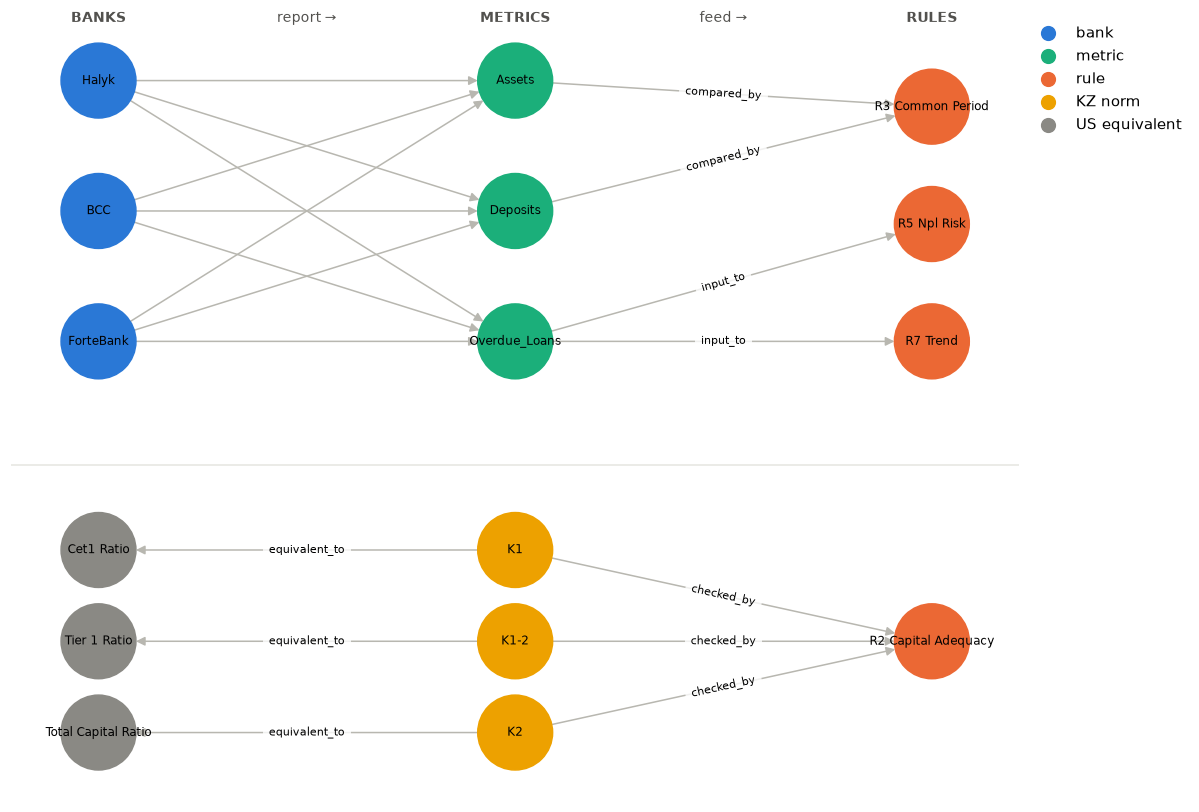

In [27]:
import networkx as nx
g = kb.build_graph(["Народный Банк Казахстана (Halyk Bank)", "Банк ЦентрКредит", "ForteBank"])
kind_color = {"bank": BLUE, "metric": AQUA, "rule": ORANGE, "kz_norm": YELLOW, "us_concept": GREY}
pos = {}
for x, kind in ((0, "bank"), (1, "metric")):
    nodes = [n for n in g if g.nodes[n].get("kind") == kind]
    for i, n in enumerate(nodes): pos[n] = (x, 1 + (len(nodes) - 1) / 2 - i)
for i, n in enumerate(["R3 common period", "R5 NPL risk", "R7 trend"]): pos[n] = (2, 1.8 - i * 0.9)
for i, n in enumerate(["CET1 ratio", "Tier 1 ratio", "Total capital ratio"]): pos[n] = (0, -1.6 - i * 0.7)
for i, n in enumerate(["k1", "k1-2", "k2"]): pos[n] = (1, -1.6 - i * 0.7)
pos["R2 capital adequacy"] = (2, -2.3)
fig, ax = plt.subplots(figsize=(11, 7.5))
nx.draw_networkx_edges(g, pos, ax=ax, edge_color="#b8b7b0", arrowsize=12, width=1, node_size=2400)
nx.draw_networkx_nodes(g, pos, ax=ax, node_size=2400, node_color=[kind_color[g.nodes[n]["kind"]] for n in g])
nx.draw_networkx_labels(g, pos, labels={n: short(n) for n in g}, ax=ax, font_size=8)
rel = {e: r for e, r in nx.get_edge_attributes(g, "rel").items() if r != "reports"}
nx.draw_networkx_edge_labels(g, pos, edge_labels=rel, font_size=7, ax=ax, bbox={"fc": "white", "ec": "none", "alpha": 0.8})
for x, text in [(0, "BANKS"), (0.5, "report →"), (1, "METRICS"), (1.5, "feed →"), (2, "RULES")]:
    ax.text(x, 2.45, text, ha="center", fontsize=9, color="#52514e", weight="bold" if text.isupper() else "normal")
for k, c in [("bank", BLUE), ("metric", AQUA), ("rule", ORANGE), ("KZ norm", YELLOW), ("US equivalent", GREY)]:
    ax.scatter([], [], color=c, s=80, label=k)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0)); ax.axhline(-0.95, color="#e6e5e0", lw=1)
ax.set_axis_off(); plt.tight_layout(); plt.show()

## 9. Integration: Input → Perception → Attention → Memory → Knowledge → Output

In [28]:
def show_trace(t, title):
    pr = t.perception
    what = [INTENT.get(pr.intent, pr.intent)]
    if pr.companies: what.append("banks: " + ", ".join(short(c) for c in pr.companies))
    if pr.metrics: what.append("measure: " + ", ".join(MEANING.get(x, x) for x in pr.metrics))
    if pr.ratios: what.append("ratio: " + ", ".join(pr.ratios))
    if pr.currencies: what.append("currency: " + ", ".join(pr.currencies))
    if pr.on_date: what.append(f"date: {pr.on_date}")
    rules = "<br>".join(f"**{k.rule}**: {k.conclusion}" for k in t.knowledge) or "-"
    sel = t.attention.get("selected") or ["nothing above threshold"]
    display(Markdown(f"""
#### {title}
| step | result |
|---|---|
| **Input** | {t.input} |
| **Perception** | {'; '.join(what)} |
| **Attention** | {t.attention.get('criterion', '')}<br>selected: {', '.join(short(s) for s in sel)} |
| **Memory** | read: {'; '.join(t.memory.get('read') or ['-'])}<br>long-term write: {t.memory.get('written_long_term')} |
| **Knowledge** | {rules} |
| **Output** | {t.output.replace(chr(10), '<br>')} |
"""))

LongTermMemory("demo@bank.kz", consent=True).forget()
demo = CognitiveAgent("demo@bank.kz", consent=True, today=TODAY)

In [29]:
show_trace(demo.handle("У каких банков самые проблемные кредиты?"), "Example 1: Risk ranking")


#### Example 1: Risk ranking
| step | result |
|---|---|
| **Input** | У каких банков самые проблемные кредиты? |
| **Perception** | risk check; measure: просрочка / NPL |
| **Attention** | приоритет по доле проблемных кредитов (порог 3%) и её росту за год (> 1 п.п.)<br>selected: VTB, Home Credit, BNK |
| **Memory** | read: -<br>long-term write: True |
| **Knowledge** | **R5 NPL risk**: VTB Kazakhstan: проблемные кредиты 9.27% портфеля на 2026-07-31 → риск ВЫСОКИЙ (порог 3%)<br>**R5 NPL risk**: Home Credit Bank: проблемные кредиты 7.48% портфеля на 2026-07-31 → риск ВЫСОКИЙ (порог 3%)<br>**R5 NPL risk**: коммерческий банк биэнкей: проблемные кредиты 7.43% портфеля на 2026-07-31 → риск ВЫСОКИЙ (порог 3%)<br>**R7 trend**: ForteBank: проблемные кредиты 3.01% (2025-06-30) → 4.32% (2026-07-31), +1.32 п.п. за год → УХУДШАЕТСЯ<br>**R7 trend**: Home Credit Bank: проблемные кредиты 5.95% (2025-06-30) → 7.48% (2026-07-31), +1.54 п.п. за год → УХУДШАЕТСЯ<br>**R7 trend**: Kaspi Bank: проблемные кредиты 5.20% (2025-06-30) → 6.82% (2026-07-31), +1.62 п.п. за год → УХУДШАЕТСЯ |
| **Output** | Наибольшая доля проблемных кредитов: VTB Kazakhstan: проблемные кредиты 9.27% портфеля на 2026-07-31 → риск ВЫСОКИЙ (порог 3%); Home Credit Bank: проблемные кредиты 7.48% портфеля на 2026-07-31 → риск ВЫСОКИЙ (порог 3%); коммерческий банк биэнкей: проблемные кредиты 7.43% портфеля на 2026-07-31 → риск ВЫСОКИЙ (порог 3%)<br>Качество ухудшается: ForteBank: проблемные кредиты 3.01% (2025-06-30) → 4.32% (2026-07-31), +1.32 п.п. за год → УХУДШАЕТСЯ; Home Credit Bank: проблемные кредиты 5.95% (2025-06-30) → 7.48% (2026-07-31), +1.54 п.п. за год → УХУДШАЕТСЯ; Kaspi Bank: проблемные кредиты 5.20% (2025-06-30) → 6.82% (2026-07-31), +1.62 п.п. за год → УХУДШАЕТСЯ<br>Не в рейтинге (последний отчёт старше квартала): Bank of China Kazakhstan, Citibank Kazakhstan, ICBC Almaty |


In [30]:
show_trace(demo.handle("Сравни активы Kaspi и Halyk"), "Example 2: Bank comparison")


#### Example 2: Bank comparison
| step | result |
|---|---|
| **Input** | Сравни активы Kaspi и Halyk |
| **Perception** | comparison; banks: Kaspi, Halyk; measure: активы |
| **Attention** | из всех отчётных периодов берётся последний, общий для всех компаний<br>selected: Nbk_Assets @ 2026-07-31 |
| **Memory** | read: -<br>long-term write: True |
| **Knowledge** | **R3 common period**: активы на 2026-07-31 (последний общий период): Народный Банк Казахстана (Halyk Bank): 21,47 трлн KZT; Kaspi Bank: 10,54 трлн KZT<br>**R4 freshness**: данные nbk_stats от 2026-07-31: 59 дн. при допустимых 75 → актуальны |
| **Output** | активы на 2026-07-31 (последний общий период): Народный Банк Казахстана (Halyk Bank): 21,47 трлн KZT; Kaspi Bank: 10,54 трлн KZT |


In [31]:
show_trace(demo.handle("А депозиты?"), "Example 3: Follow-up from memory")


#### Example 3: Follow-up from memory
| step | result |
|---|---|
| **Input** | А депозиты? |
| **Perception** | single figure; banks: Kaspi, Halyk; measure: вклады |
| **Attention** | из всех отчётных периодов берётся последний, общий для всех компаний<br>selected: Nbk_Deposits @ 2026-07-31 |
| **Memory** | read: company <- short-term memory: ['Kaspi Bank', 'Народный Банк Казахстана (Halyk Bank)']<br>long-term write: True |
| **Knowledge** | **R3 common period**: вклады клиентов на 2026-07-31 (последний общий период): Народный Банк Казахстана (Halyk Bank): 14,66 трлн KZT; Kaspi Bank: 8,73 трлн KZT<br>**R4 freshness**: данные nbk_stats от 2026-07-31: 59 дн. при допустимых 75 → актуальны |
| **Output** | вклады клиентов на 2026-07-31 (последний общий период): Народный Банк Казахстана (Halyk Bank): 14,66 трлн KZT; Kaspi Bank: 8,73 трлн KZT |


In [32]:
show_trace(demo.handle("Соблюдает ли Kaspi норматив k2?"), "Example 4: Capital norm check")


#### Example 4: Capital norm check
| step | result |
|---|---|
| **Input** | Соблюдает ли Kaspi норматив k2? |
| **Perception** | norm check; banks: Kaspi; ratio: k2 |
| **Attention** | последнее значение норматива k2 этого банка из данных НБ РК<br>selected: Kaspi Bank: K2 |
| **Memory** | read: -<br>long-term write: True |
| **Knowledge** | **R2 capital adequacy**: Kaspi Bank: k2 (достаточность собственного капитала) = 14.3% на 2026-07-31; минимум 8.0% → СОБЛЮДАЕТСЯ (запас +6.3%)<br>**R4 freshness**: данные nbk_stats от 2026-07-31: 59 дн. при допустимых 75 → актуальны |
| **Output** | Kaspi Bank: k2 (достаточность собственного капитала) = 14.3% на 2026-07-31; минимум 8.0% → СОБЛЮДАЕТСЯ (запас +6.3%) |


In [33]:
show_trace(demo.handle("Какой NPL у Нурбанка?"), "Example 5: Single-bank risk")


#### Example 5: Single-bank risk
| step | result |
|---|---|
| **Input** | Какой NPL у Нурбанка? |
| **Perception** | risk check; banks: Nurbank; measure: просрочка / NPL |
| **Attention** | приоритет по доле проблемных кредитов (порог 3%) и её росту за год (> 1 п.п.)<br>selected: Nurbank |
| **Memory** | read: -<br>long-term write: True |
| **Knowledge** | **R5 NPL risk**: Нурбанк: проблемные кредиты 4.94% портфеля на 2026-07-31 → риск ВЫСОКИЙ (порог 3%) |
| **Output** | Наибольшая доля проблемных кредитов: Нурбанк: проблемные кредиты 4.94% портфеля на 2026-07-31 → риск ВЫСОКИЙ (порог 3%) |


In [34]:
show_trace(demo.handle("В какие сроки банковский конгломерат представляет отчет о выполнении пруденциальных нормативов?"), "Example 6: Regulation lookup")


#### Example 6: Regulation lookup
| step | result |
|---|---|
| **Input** | В какие сроки банковский конгломерат представляет отчет о выполнении пруденциальных нормативов? |
| **Perception** | regulation |
| **Attention** | cross-encoder relevance ≥ 0.3<br>selected: Глава 4, Пункт 11, Глава 2, Приложение 8, Пункт 5, Глава 1, Пункт 6 |
| **Memory** | read: -<br>long-term write: True |
| **Knowledge** | **R6 grounding**: ответ прошёл проверку |
| **Output** | Отчет о выполнении пруденциальных нормативов банковским конгломератом представляется:<br>- ежеквартально (за исключением четвертого квартала) не позднее 70 календарных дней, следующих за отчетным кварталом [1];<br>- ежегодно не позднее 31 мая года, следующего за отчетным годом [1].<br><br>Источники: [1] Об утверждении Правил представления отчетности о выполнении пруденциал, Глава 4, пункт 11; [2] О внесении изменений и дополнений в некоторые нормативные правовые акт, Глава 2, Приложение 8, пункт 5; [3] Об утверждении Правил представления отчетности о выполнении пруденциал, Глава 1, пункт 6 |


In [35]:
show_trace(demo.handle("Какой курс доллара был вчера?"), "Example 7: Exchange rate, relative date")


#### Example 7: Exchange rate, relative date
| step | result |
|---|---|
| **Input** | Какой курс доллара был вчера? |
| **Perception** | exchange rate; currency: USD; date: 2026-09-27 |
| **Attention** | курс USD на дату 2026-09-27; если дата не рабочая — ближайшая предыдущая<br>selected: Usd 2026-09-26 (Ближайший Опубликованный) |
| **Memory** | read: -<br>long-term write: True |
| **Knowledge** | **R4 freshness**: данные nbk от 2026-09-26: 2 дн. при допустимых 2 → актуальны |
| **Output** | Официальный курс НБ РК на 2026-09-26: 1 USD = 441,88 тенге (Официальные курсы валют НБРК на 26.09.2026) |


In [36]:
show_trace(demo.handle("Рецепт приготовления борща"), "Example 8: Out-of-scope refusal")


#### Example 8: Out-of-scope refusal
| step | result |
|---|---|
| **Input** | Рецепт приготовления борща |
| **Perception** | regulation |
| **Attention** | cross-encoder relevance ≥ 0.3<br>selected: Nothing Above Threshold |
| **Memory** | read: -<br>long-term write: True |
| **Knowledge** | **R6 grounding**: лучший фрагмент 0.0011 < порога 0.3 → отказ |
| **Output** | НЕТ ДАННЫХ В ИСТОЧНИКАХ: в корпусе нет документов по этому вопросу. |
